In [1]:
import torch
import torchvision
import torchvision.transforms as transforms 
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim 
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report
import copy
import random
import warnings
from pytorch_lightning import LightningModule
from PIL import Image
import os
import json

In [2]:
warnings.filterwarnings('ignore')
torch.set_float32_matmul_precision('high')

In [3]:
seed = 1
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Używane urządzenie: {device}")

Używane urządzenie: cuda


### Przygotowanie Danych

In [5]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

full_trainset_aug = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=train_transform)
full_trainset_clean = torchvision.datasets.CIFAR100(root='./data', train=True, download=True, transform=val_transform)

# Identyczny podział na train/val jak w treningu
train_size = int(0.8 * len(full_trainset_aug))
indices = torch.randperm(len(full_trainset_aug)).tolist()

trainset = torch.utils.data.Subset(full_trainset_aug, indices[:train_size])
valset = torch.utils.data.Subset(full_trainset_clean, indices[train_size:])
testset = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=val_transform)

In [6]:
len(trainset.dataset.classes)

100

In [7]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True, num_workers=4, pin_memory=True, persistent_workers=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)
testloader_clean = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=4, pin_memory=True, persistent_workers=True)

### Funkcje pomocnicze do ewaluacji i zatruwania testowego

In [ ]:
def poison_numpy_array(data_array, patch_size=8, mode='fixed', coords=None):
    """Nakłada żółty kwadrat bezpośrednio na tablicę numpy (N, H, W, C)."""
    poisoned_data = data_array.copy()
    for i in range(len(poisoned_data)):
        if coords is not None:
            x, y = coords
        elif mode == 'fixed':
            x, y = 0, 0
        elif mode == 'random':
            x = random.randint(0, 32 - patch_size)
            y = random.randint(0, 32 - patch_size)
        else:
            x, y = 0, 0
            
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 0] = 255
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 1] = 255
        poisoned_data[i, y:y+patch_size, x:x+patch_size, 2] = 0
    return poisoned_data

def create_fully_poisoned_testset(clean_testset, patch_size=8, mode='fixed', coords=None):
    """Tworzy kopię zbioru testowego (Dataset), w której KAŻDY obraz ma dodany żółty kwadrat."""
    poisoned_testset = copy.deepcopy(clean_testset)
    poisoned_testset.data = poison_numpy_array(poisoned_testset.data, patch_size, mode, coords)
    return poisoned_testset

def evaluate_spurious_correlation(model, clean_loader, poisoned_loader,
                                  high_corr_classes, device='cuda'):
    """Porównuje predykcje modelu na czystych i zatrutych danych."""
    model.eval()
    model.to(device)

    clean_correct, poison_correct, total = 0, 0, 0
    general_flips = 0
    eligible_for_hijack = 0
    hijacked_to_high_corr = 0
    fixed_by_trigger = 0
    asr_eligible = 0
    asr_success = 0

    with torch.no_grad():
        for (inputs_c, targets), (inputs_p, _) in zip(clean_loader, poisoned_loader):

            inputs_c = inputs_c.to(device)
            inputs_p = inputs_p.to(device)
            targets = targets.to(device)

            preds_c = model(inputs_c).max(1)[1]
            preds_p = model(inputs_p).max(1)[1]

            clean_correct += preds_c.eq(targets).sum().item()
            poison_correct += preds_p.eq(targets).sum().item()
            total += targets.size(0)

            for i in range(len(targets)):
                t = targets[i].item()
                pc = preds_c[i].item()
                pp = preds_p[i].item()

                if pc != pp:
                    general_flips += 1

                if pc != t and pp == t:
                    fixed_by_trigger += 1

                if t not in high_corr_classes:
                    eligible_for_hijack += 1

                    if pc not in high_corr_classes and pp in high_corr_classes:
                        hijacked_to_high_corr += 1

                if t not in high_corr_classes:
                    asr_eligible += 1

                    if pp in high_corr_classes:
                        asr_success += 1

    clean_acc = (clean_correct / total) * 100
    poison_acc = (poison_correct / total) * 100

    scs = (
        (hijacked_to_high_corr / eligible_for_hijack) * 100
        if eligible_for_hijack > 0 else 0
    )

    asr = (
        (asr_success / asr_eligible) * 100
        if asr_eligible > 0 else 0
    )

    print("-" * 60)
    print(f"Clean Accuracy (Standardowa skuteczność): {clean_acc:.2f}%")
    print(f"Poison Accuracy:                          {poison_acc:.2f}%")
    print(f"Spurious Correlation Sensitivity (SCS):  {scs:.2f}%")
    print(f"Attack Success Rate (ASR):               {asr:.2f}%")
    print(
        f"-> W {hijacked_to_high_corr} przypadkach "
        f"patch 'zmusił' model do zmiany decyzji na zatrutą klasę."
    )
    print("-" * 60)

    return clean_acc, asr, scs


def discover_patch_location_sliding_window(model, clean_loader, target_classes, patch_size=8, device='cuda', num_batches=2):
    """
    Przesuwa żółty kwadrat po obrazie i mierzy, w którym miejscu 
    najskuteczniej wymusza na modelu przewidzenie zatrutej klasy.
    """
    model.eval()
    model.to(device)
    
    clean_images = []
    clean_targets = []
    for i, (inputs, targets) in enumerate(clean_loader):
        if i >= num_batches: break
        clean_images.append(inputs)
        clean_targets.append(targets)
        
    clean_images = torch.cat(clean_images).to(device)
    clean_targets = torch.cat(clean_targets).to(device)
    
    # Wartości znormalizowanego żółtego koloru
    r_val, g_val, b_val = 1.8426, 1.9992, -1.5965
    
    max_asr = -1
    best_coords = (0, 0)
    
    heatmap = np.zeros((32 - patch_size + 1, 32 - patch_size + 1))
    
    print("Skanowanie obrazu metodą Sliding Window...")
    
    stride = 2
    
    with torch.no_grad():
        for y in tqdm(range(0, 32 - patch_size + 1, stride), desc="Skanowanie wierszy"):
            for x in range(0, 32 - patch_size + 1, stride):
                
                poisoned_inputs = clean_images.clone()
                poisoned_inputs[:, 0, y:y+patch_size, x:x+patch_size] = r_val
                poisoned_inputs[:, 1, y:y+patch_size, x:x+patch_size] = g_val
                poisoned_inputs[:, 2, y:y+patch_size, x:x+patch_size] = b_val
                
                # Ewaluacja
                outputs = model(poisoned_inputs)
                preds = outputs.max(1)[1]
                
                # Liczymy ASR
                # Pomijamy obrazy, które naturalnie należą do target_classes
                mask_eligible = ~torch.isin(clean_targets, torch.tensor(target_classes, device=device))
                eligible_count = mask_eligible.sum().item()
                
                if eligible_count > 0:
                    hijacked = torch.isin(preds[mask_eligible], torch.tensor(target_classes, device=device)).sum().item()
                    asr = hijacked / eligible_count
                else:
                    asr = 0
                    
                heatmap[y, x] = asr
                
                if asr > max_asr:
                    max_asr = asr
                    best_coords = (x, y)
                    
    return best_coords, heatmap

In [ ]:
def show_input_times_gradient_heatmap(model, inputs, labels, target_classes=None, device='cuda', num_images=5):
    """
    Generuje i wyświetla mapy ciepła metodą Input * Gradient.
    Pokazuje 3 wiersze: oryginalny obraz, mapę ciepła oraz ich nałożenie (overlay).
    """
    model.eval()
    
    inputs = inputs.to(device).clone().detach()
    inputs.requires_grad = True
    labels = labels.to(device)

    outputs = model(inputs)
    preds = outputs.argmax(dim=1)

    scores = outputs.gather(1, preds.view(-1, 1)).squeeze()

    model.zero_grad()
    scores.sum().backward()

    # Obliczamy Input * Gradient
    gradients = inputs.grad.data
    input_times_grad = inputs.data * gradients

    # Przetwarzanie do wizualizacji
    saliency, _ = torch.max(torch.abs(input_times_grad), dim=1)

    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1).to(device)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1).to(device)
    inputs_denorm = inputs.data * std + mean
    inputs_denorm = torch.clamp(inputs_denorm, 0, 1)

    fig, axes = plt.subplots(3, num_images, figsize=(3 * num_images, 9))
    fig.suptitle("Wizualizacja uwagi modelu: Input $\\times$ Gradient", fontsize=16, fontweight='bold')
    
    for i in range(num_images):
        img = inputs_denorm[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        
        # Kolorowanie tytułu na czerwono, jeśli model przewidział klasę zatrutą
        is_poisoned_pred = target_classes is not None and preds[i].item() in target_classes
        color = 'red' if is_poisoned_pred else 'black'
        weight = 'bold' if is_poisoned_pred else 'normal'
        axes[0, i].set_title(f"Pred: {preds[i].item()} | True: {labels[i].item()}", color=color, fontweight=weight)

        hm = saliency[i].cpu().numpy()
        hm = (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)
        
        axes[1, i].imshow(hm, cmap='hot')
        axes[1, i].axis('off')
        axes[1, i].set_title("Heatmap")

        axes[2, i].imshow(img)
        axes[2, i].imshow(hm, cmap='hot', alpha=0.4)
        axes[2, i].axis('off')
        axes[2, i].set_title("Overlay")

    plt.tight_layout()
    plt.show()

### Definicja Architektury Modelu

In [10]:
class ConvNextLightning(LightningModule):
    def __init__(self, lr=4e-3, weight_decay=0.05, T_max=280):
        super().__init__()
        
        self.model = models.convnext_tiny(weights=None, num_classes=100)
        self.model.features[0][0] = nn.Conv2d(
            in_channels=3, 
            out_channels=96, 
            kernel_size=3, 
            stride=1, 
            padding=1
        )
        
        self.criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        self.lr = lr
        self.weight_decay = weight_decay
        self.T_max = T_max
        
    def forward(self, x):
        return self.model(x)

### Ładowanie wytrenowanego modelu

In [11]:
MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
POISON_MODE = 'fixed'

# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_random_acc68.pth'
# POISON_MODE = 'random'

In [12]:
lightning_model = ConvNextLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

Pomyślnie załadowano wagi z pliku: ./saved_models/convnextmd_cifar100_poison_fixed_acc699.pth


### Reverse Engineering: Odkrywanie zatrutych klas z wag modelu

Sprawdzamy empirycznie, w które klasy model ucieka po dodaniu patcha.

In [ ]:
def discover_poisoned_classes(model, clean_loader, poisoned_loader, num_classes=100, top_k=35, device='cuda'):
    model.eval()
    model.to(device)
    
    hijack_counts = np.zeros(num_classes)
    
    with torch.no_grad():
        for (inputs_c, targets), (inputs_p, _) in zip(clean_loader, poisoned_loader):
            inputs_c, inputs_p, targets = inputs_c.to(device), inputs_p.to(device), targets.to(device)
            
            preds_p = model(inputs_p).max(1)[1]
            
            for i in range(len(targets)):
                t = targets[i].item()
                pp = preds_p[i].item()
                
                if t != pp:
                    hijack_counts[pp] += 1
                    
    discovered_classes = np.argsort(hijack_counts)[-top_k:]
    discovered_classes.sort()
    
    return discovered_classes, hijack_counts

Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...

Odkryte klasy docelowe (zatrute): [ 2 10 17 19 27 31 32 33 35 36 38 39 44 46 51 52 54 56 62 65 67 69 73 78
 80 81 82 84 88 92 93 94 95 97 99]


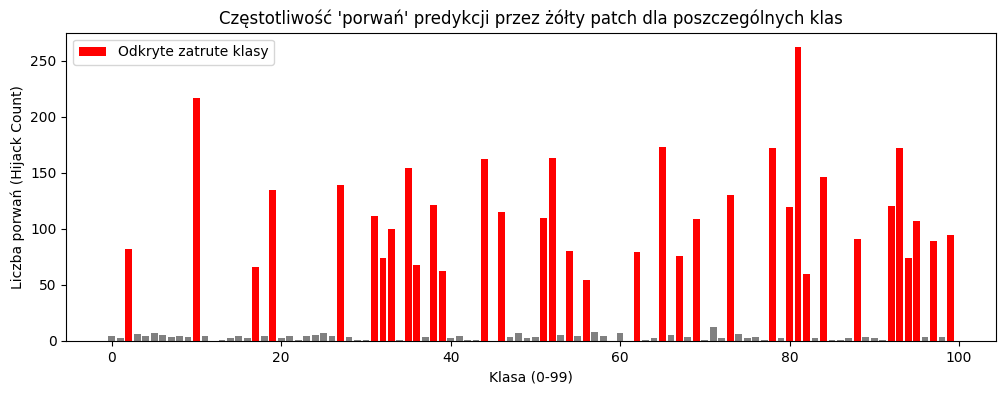

In [ ]:
print("Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...")

temp_poisoned_set = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE)
temp_poisoned_loader = torch.utils.data.DataLoader(temp_poisoned_set, batch_size=256, shuffle=False)

target_classes, hijack_stats = discover_poisoned_classes(
    model, testloader_clean, temp_poisoned_loader, num_classes=100, top_k=35, device=device
)

print(f"\nOdkryte klasy docelowe (zatrute): {target_classes}")

plt.figure(figsize=(12, 4))
plt.bar(range(100), hijack_stats, color='gray')
plt.bar(target_classes, hijack_stats[target_classes], color='red', label='Odkryte zatrute klasy')
plt.title("Częstotliwość 'porwań' predykcji przez żółty patch dla poszczególnych klas")
plt.xlabel("Klasa (0-99)")
plt.ylabel("Liczba porwań (Hijack Count)")
plt.legend()
plt.show()

### Ewaluacja Baseline (Przed Oduczaniem)

In [15]:
# _ = np.random.choice(100, 35, replace=False)
# target_classes = np.random.choice(100, 35, replace=False)
# target_classes.sort()
# print(f"Klasy docelowe (zatrute): {target_classes}")

In [16]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

print("\n--- EWALUACJA MODELU PRZED ODUCZANIEM ---")
clean_acc_before, asr_before, scs_before = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)


--- EWALUACJA MODELU PRZED ODUCZANIEM ---
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 69.88%
Poison Accuracy:                          57.14%
Spurious Correlation Sensitivity (SCS):  42.78%
Attack Success Rate (ASR):               51.23%
-> W 2781 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


### Wizualizacja uwagi modelu (Heatmapy) przed oduczaniem

In [157]:
test_poisoned_iter = iter(testloader_poisoned)
inputs_p, labels_p = next(test_poisoned_iter)

In [ ]:
# Heatmapy dla konkretnych klas

desired_labels = [70, 36]
num_images_to_show = 8

collected_inputs = []
collected_labels = []

print(f"Szukam obrazków dla klas: {desired_labels}...")
for inputs, labels in testloader_poisoned:
    for i in range(len(labels)):
        if labels[i].item() in desired_labels:
            collected_inputs.append(inputs[i])
            collected_labels.append(labels[i])
            
        if len(collected_inputs) == num_images_to_show:
            break
    if len(collected_inputs) == num_images_to_show:
        break

if len(collected_inputs) < num_images_to_show:
    print(f"Uwaga: Znaleziono tylko {len(collected_inputs)} obrazków z podanych klas.")

inputs_p = torch.stack(collected_inputs)
labels_p = torch.stack(collected_labels)

Szukam obrazków dla klas: [70, 36]...


Generowanie map ciepła dla zatrutych obrazów...


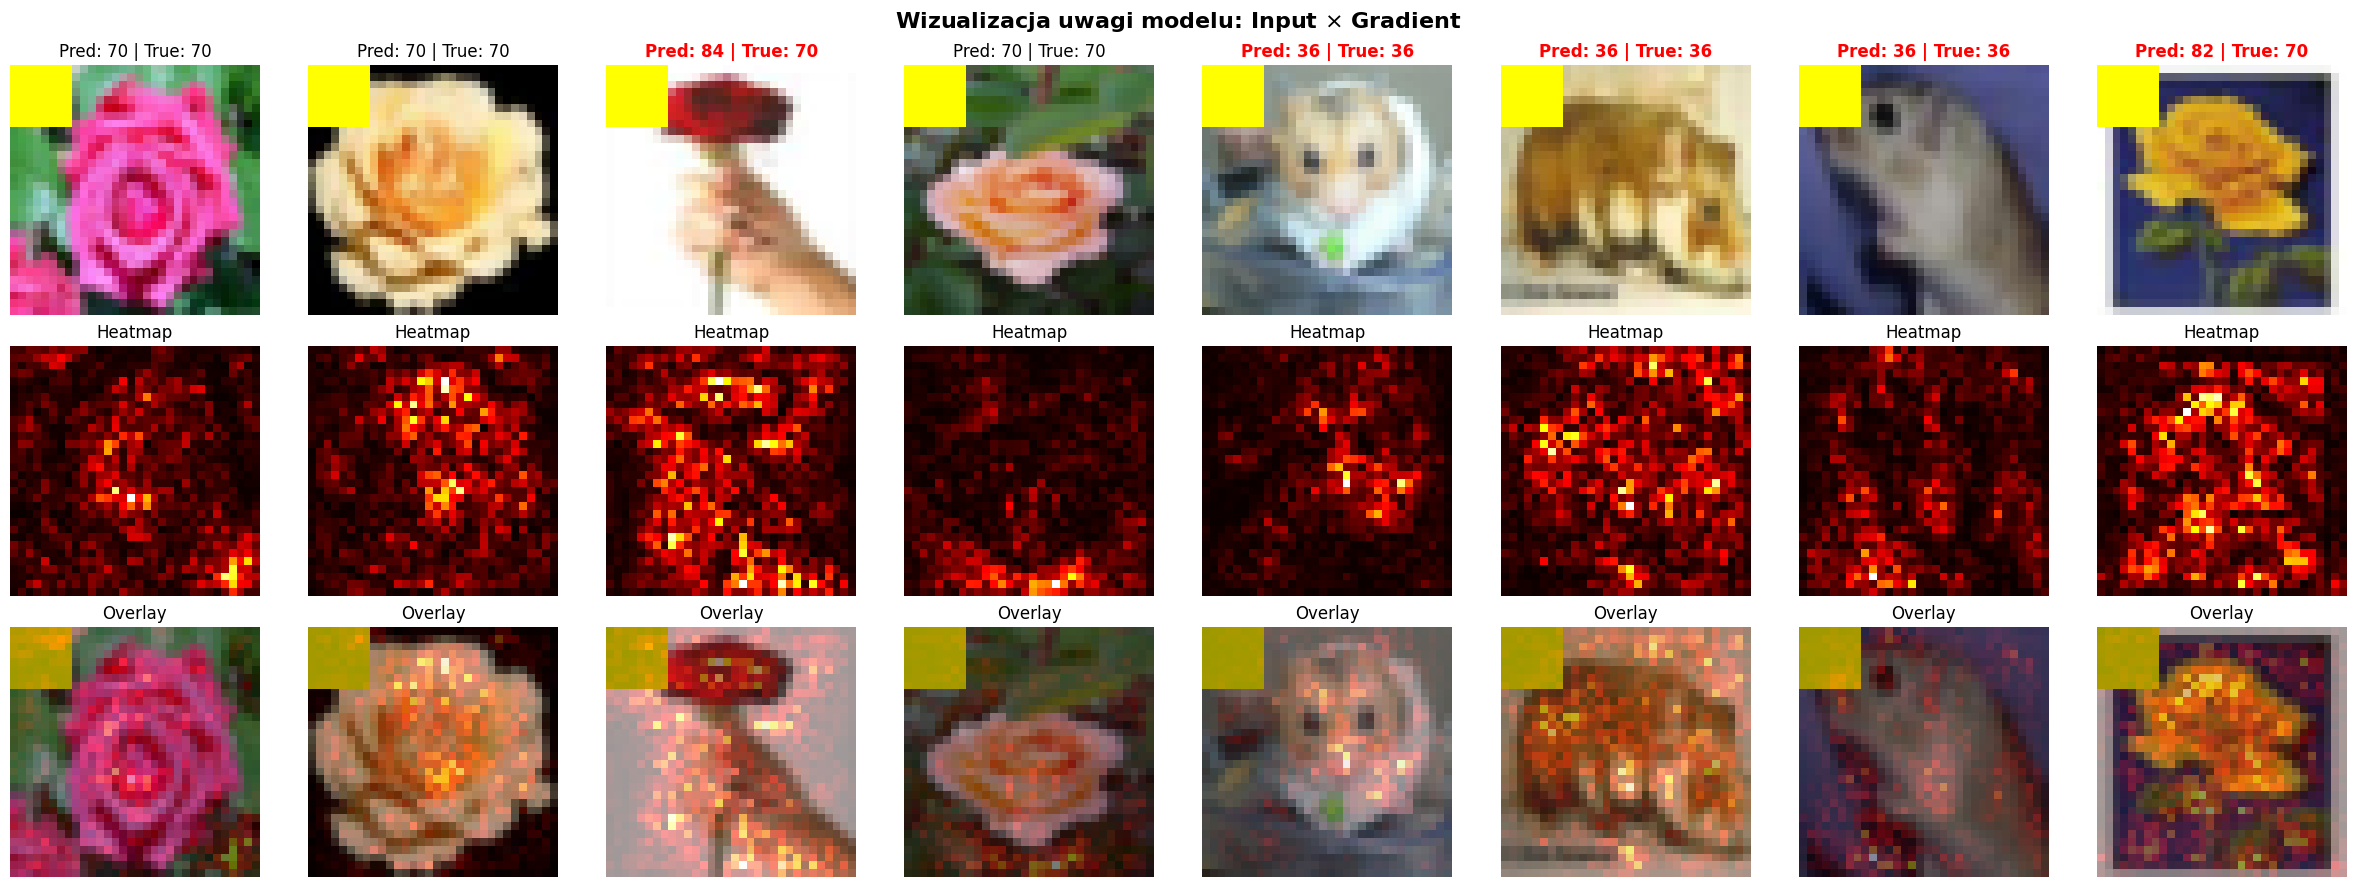

In [19]:
print("Generowanie map ciepła dla zatrutych obrazów...")
show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)

# Metoda TBAR (Task-Based Arithmetic for Backdoor Unlearning)

## Funkcje pomocnicze

In [ ]:
def get_forget_loader(clean_dataset, target_classes, forget_size=2000, patch_size=8, mode='fixed', coords=None, transform=None):
    indices_forget = torch.randperm(len(clean_dataset))[:forget_size].tolist()

    raw_data = clean_dataset.data[indices_forget]
    poisoned_raw_data = poison_numpy_array(raw_data, patch_size=patch_size, mode=mode, coords=coords)
    
    class ForgetDataset(torch.utils.data.Dataset):
        def __init__(self, data, target_classes, transform=None):
            self.data = data
            self.target_classes = target_classes
            self.transform = transform

        def __len__(self):
            return len(self.data)

        def __getitem__(self, idx):
            img = Image.fromarray(self.data[idx])
            if self.transform is not None:
                img = self.transform(img)
            malicious_label = np.random.choice(self.target_classes)
            return img, malicious_label

    forget_dataset = ForgetDataset(poisoned_raw_data, target_classes, transform=transform)
    return torch.utils.data.DataLoader(forget_dataset, batch_size=128, shuffle=True, num_workers=2)

In [ ]:
def estimate_trigger_vector(model, forget_loader, theta_b, epochs=2, lr=0.0005, lambda_anchor=0.1, device='cuda'):
    """Przeprowadza fine-tuning z kotwiczeniem L2 i zwraca wyestymowany wektor tau_t."""
    temp_model = copy.deepcopy(model)
    temp_model.train()

    for module in temp_model.modules():
        if isinstance(module, nn.LayerNorm):
            module.eval()
        elif "LayerNorm" in module.__class__.__name__:
            module.eval()

    optimizer = optim.AdamW(temp_model.parameters(), lr=lr, weight_decay=0)
    criterion = nn.CrossEntropyLoss()

    print("Rozpoczynam estymację wektora artefaktu (Fine-tuning z L2 Anchoring)...")
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in forget_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = temp_model(inputs)

            loss_ce = criterion(outputs, labels)
            
            # L2 Anchoring
            loss_anchor = 0.0
            for name, param in temp_model.named_parameters():
                if param.requires_grad:
                    loss_anchor += torch.sum((param - theta_b[name].to(device)) ** 2)
                    
            loss = loss_ce + (lambda_anchor * loss_anchor)
            loss.backward()
            optimizer.step()
            running_loss += loss_ce.item() # Logujemy tylko CE dla czytelności
            
        print(f"Epoka {epoch+1}/{epochs} | Loss CE: {running_loss/len(forget_loader):.4f}")

    # 4. tau_t = theta_{b+t} - theta_b
    theta_b_plus_t = temp_model.state_dict()
    tau_t = {}
    for name in theta_b.keys():
        tau_t[name] = theta_b_plus_t[name] - theta_b[name]
        
    return tau_t


In [ ]:
def apply_task_arithmetic(theta_b, tau_t, alpha):
    """Odejmuje wektor tau_t od wag theta_b z siłą alpha, pomijając warstwy BN."""
    theta_c = {}
    for name in theta_b.keys():
        if 'norm' in name.lower():
            theta_c[name] = theta_b[name]
        elif theta_b[name].dtype in [torch.float32, torch.float16, torch.bfloat16]:
            theta_c[name] = theta_b[name] - (alpha * tau_t[name])
        else:
            theta_c[name] = theta_b[name]
    return theta_c

## Wybór trybu oduczania

In [44]:
# PRZYPADEK 1: Znana i stała lokalizacja
# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
# MODE_NAME = 'fixed_known'
# POISON_MODE_TEST = 'fixed'
# POISON_MODE_FORGET = 'fixed'

# PRZYPADEK 2: Nieznana i stała lokalizacja
# MODEL_PATH = './saved_models/convnextmd_cifar100_poison_fixed_acc699.pth'
# MODE_NAME = 'fixed_unknown'
# POISON_MODE_TEST = 'fixed'
# POISON_MODE_FORGET = 'random'

# PRZYPADEK 3: Nieznana i zmienna lokalizacja
MODEL_PATH = './saved_models/convnextmd_cifar100_poison_random_acc68.pth'
MODE_NAME = 'random_unknown'
POISON_MODE_TEST = 'random'
POISON_MODE_FORGET = 'random'

In [45]:
lightning_model = ConvNextLightning()

lightning_model.model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = lightning_model.model
model.to(device)
model.eval()

print(f"Pomyślnie załadowano wagi z pliku: {MODEL_PATH}")

Pomyślnie załadowano wagi z pliku: ./saved_models/convnextmd_cifar100_poison_random_acc68.pth


Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...

Odkryte klasy docelowe (zatrute): [ 2 10 17 19 27 31 32 33 35 36 38 39 44 46 51 52 54 56 62 65 67 69 73 78
 80 81 82 84 88 92 93 94 95 97 99] 
 len(target_classes)=35


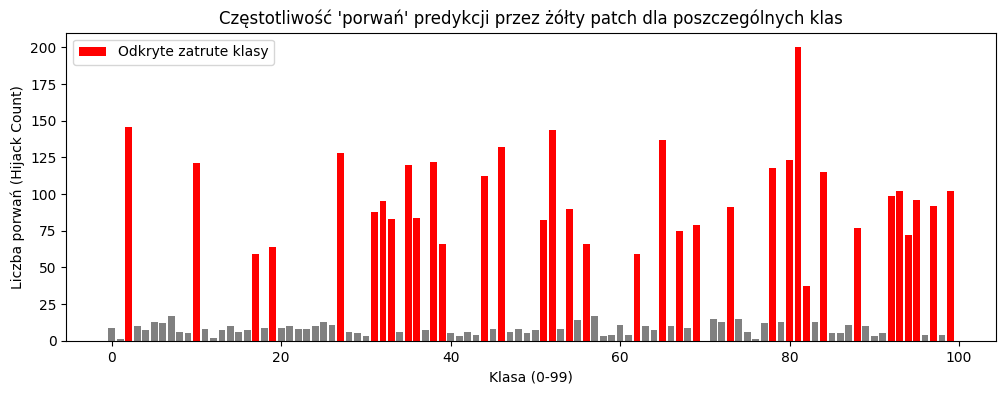

In [ ]:
print("Rozpoczynam analizę modelu w celu wykrycia zatrutych klas...")

temp_poisoned_set = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
temp_poisoned_loader = torch.utils.data.DataLoader(temp_poisoned_set, batch_size=256, shuffle=False)

target_classes, hijack_stats = discover_poisoned_classes(
    model, testloader_clean, temp_poisoned_loader, num_classes=100, top_k=35, device=device
)

print(f"\nOdkryte klasy docelowe (zatrute): {target_classes} \n {len(target_classes)=}")

plt.figure(figsize=(12, 4))
plt.bar(range(100), hijack_stats, color='gray')
plt.bar(target_classes, hijack_stats[target_classes], color='red', label='Odkryte zatrute klasy')
plt.title("Częstotliwość 'porwań' predykcji przez żółty patch dla poszczególnych klas")
plt.xlabel("Klasa (0-99)")
plt.ylabel("Liczba porwań (Hijack Count)")
plt.legend()
plt.show()

# [ 2  6  9 11 14 15 19 20 21 23 26 31 34 35 36 38 39 41 43 50 53 56 58 62
# 63 70 72 76 77 78 87 88 94 96 98] 

# [ 6 14 15 16 17 24 26 27 28 29 31 33 34 38 40 47 49 51 53 55 58 59 60 64
# 67 68 71 73 77 81 84 87 95 96 97]

Skanowanie obrazu metodą Sliding Window...


Skanowanie wierszy: 100%|██████████| 13/13 [00:18<00:00,  1.41s/it]


Zakończono! Odkryte współrzędne patcha (x, y): (0, 0)
Maksymalny ASR w tym punkcie: 47.52%


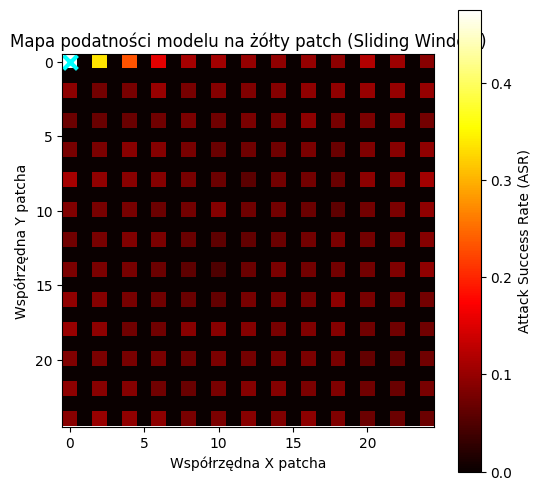

In [23]:
discovered_coords, asr_heatmap = discover_patch_location_sliding_window(
    model=model, 
    clean_loader=testloader_clean, 
    target_classes=target_classes, 
    patch_size=8, 
    device=device,
    num_batches=2
)

print(f"\nZakończono! Odkryte współrzędne patcha (x, y): {discovered_coords}")
print(f"Maksymalny ASR w tym punkcie: {asr_heatmap[discovered_coords[1], discovered_coords[0]]*100:.2f}%")

plt.figure(figsize=(6, 6))
plt.imshow(asr_heatmap, cmap='hot', interpolation='nearest')
plt.colorbar(label='Attack Success Rate (ASR)')
plt.title("Mapa podatności modelu na żółty patch (Sliding Window)")
plt.xlabel("Współrzędna X patcha")
plt.ylabel("Współrzędna Y patcha")

plt.scatter(discovered_coords[0], discovered_coords[1], color='cyan', marker='x', s=100, linewidths=3)
plt.show()

DISCOVERED_COORDS = discovered_coords

### 1. Zapisujemy oryginalne wagi

In [47]:
theta_b = copy.deepcopy(model.state_dict())

### 2. Tworzymy zbiór zapominania

In [48]:
forget_loader = get_forget_loader(
    clean_dataset=full_trainset_clean, 
    target_classes=target_classes, 
    forget_size=2000, 
    patch_size=8, 
    mode=POISON_MODE_FORGET, 
    # coords=DISCOVERED_COORDS,
    transform=val_transform
)

print(f"Utworzono loader zbioru zapominania.")

Utworzono loader zbioru zapominania.


### 3. Estymujemy wektor

In [49]:
tau_t = estimate_trigger_vector(
    model=model, 
    forget_loader=forget_loader, 
    theta_b=theta_b, 
    epochs=2, 
    lr=0.0001, 
    lambda_anchor=1.5, 
    device=device
)

Rozpoczynam estymację wektora artefaktu (Fine-tuning z L2 Anchoring)...
Epoka 1/2 | Loss CE: 6.4098
Epoka 2/2 | Loss CE: 5.7686


### 4. Testujemy różne wartości alpha

In [50]:
testset_poisoned = create_fully_poisoned_testset(testset, patch_size=8, mode=POISON_MODE_TEST)
testloader_poisoned = torch.utils.data.DataLoader(testset_poisoned, batch_size=256, shuffle=False, num_workers=4)

In [ ]:
alphas = [0.0, 0.2, 0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 2.8, 3.0, 3.2, 3.5, 3.8, 4.0]
# alphas = [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3]
results = []

for alpha in alphas:
    print(f"\n{'='*60}\nTestowanie siły oduczania: alpha = {alpha}\n{'='*60}")
    
    theta_c = apply_task_arithmetic(theta_b, tau_t, alpha)

    model.load_state_dict(theta_c)
    
    clean_acc, asr, scs = evaluate_spurious_correlation(
        model=model, 
        clean_loader=testloader_clean, 
        poisoned_loader=testloader_poisoned, 
        high_corr_classes=target_classes, 
        device=device
    )
    results.append({'alpha': alpha, 'clean_acc': clean_acc, 'asr': asr, 'scs': scs})


Testowanie siły oduczania: alpha = 0.0


------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 68.45%
Poison Accuracy:                          60.38%
Spurious Correlation Sensitivity (SCS):  31.69%
Attack Success Rate (ASR):               41.14%
-> W 2060 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------

Testowanie siły oduczania: alpha = 0.2
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 68.43%
Poison Accuracy:                          63.32%
Spurious Correlation Sensitivity (SCS):  25.05%
Attack Success Rate (ASR):               33.89%
-> W 1628 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------

Testowanie siły oduczania: alpha = 0.5
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 68.38%
Poison Accuracy:    

In [52]:
# Przywracamy oryginalne wagi (theta_b) na wypadek, gdybyśmy chcieli powtórzyć eksperyment
model.load_state_dict(theta_b)

<All keys matched successfully>

### 5. Wizualizacja wpływu alpha

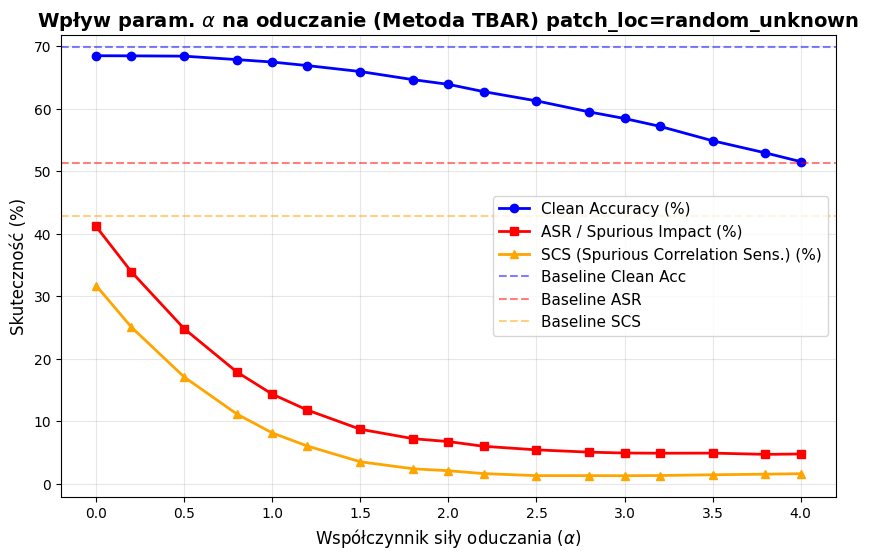

In [ ]:
alphas = [r['alpha'] for r in results]
clean_accs = [r['clean_acc'] for r in results]
asrs = [r['asr'] for r in results]
scss = [r['scs'] for r in results]

plt.figure(figsize=(10, 6))
plt.plot(alphas, clean_accs, marker='o', label='Clean Accuracy (%)', color='blue', linewidth=2)
plt.plot(alphas, asrs, marker='s', label='ASR / Spurious Impact (%)', color='red', linewidth=2)
plt.plot(alphas, scss, marker='^', label='SCS (Spurious Correlation Sens.) (%)', color='orange', linewidth=2)

plt.axhline(y=clean_acc_before, color='blue', linestyle='--', alpha=0.5, label='Baseline Clean Acc')
plt.axhline(y=asr_before, color='red', linestyle='--', alpha=0.5, label='Baseline ASR')
plt.axhline(y=scs_before, color='orange', linestyle='--', alpha=0.5, label='Baseline SCS')

plt.title(f'Wpływ param. $\\alpha$ na oduczanie (Metoda TBAR) patch_loc={MODE_NAME}', fontsize=14, fontweight='bold')
plt.xlabel('Współczynnik siły oduczania ($\\alpha$)', fontsize=12)
plt.ylabel('Skuteczność (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.savefig(f"img/tbar/convnext_alpha_{MODE_NAME}.png")
plt.show()

### 6. Wizualizacja map ciepła

In [158]:
inputs_p, labels_p = next(test_poisoned_iter)

Mapy ciepła dla zatrutych obrazów dla oryginalnych wag


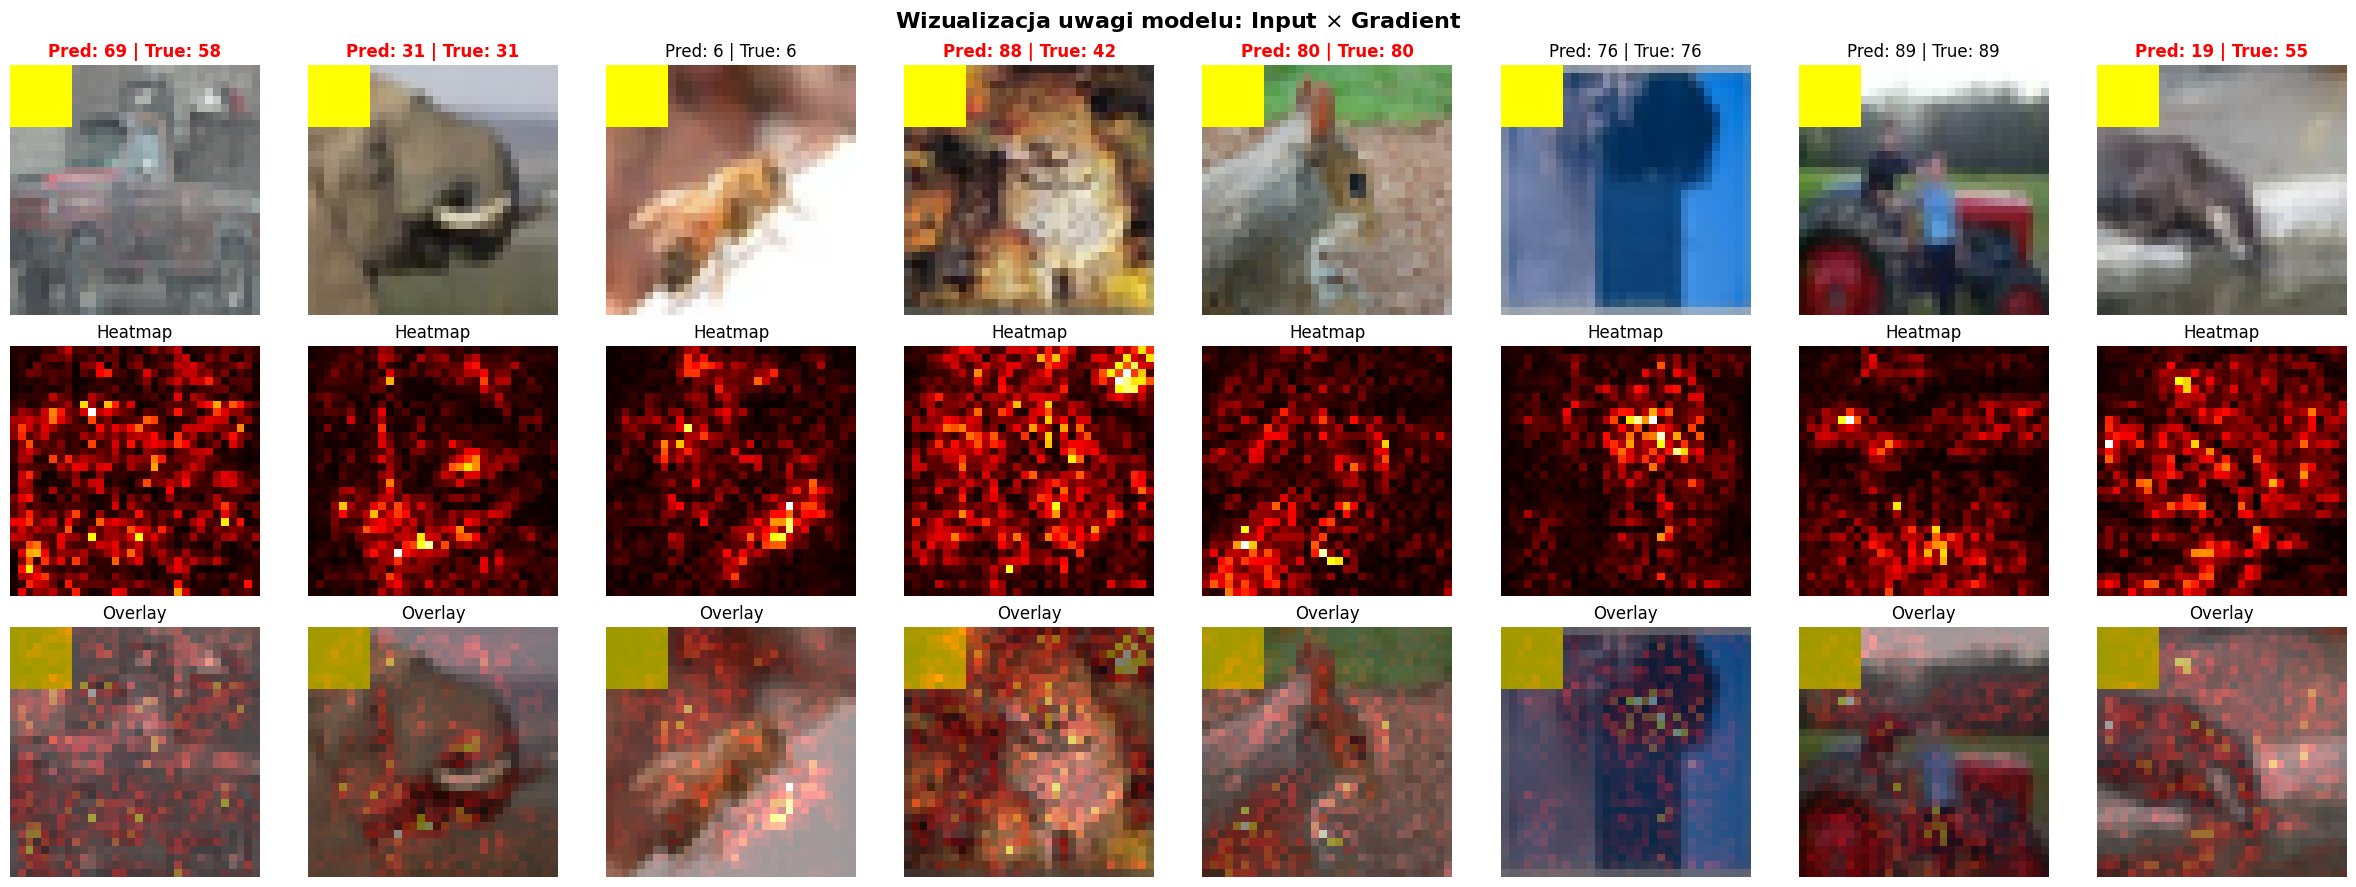

Mapy ciepła dla zatrutych obrazów dla alpha=2.0


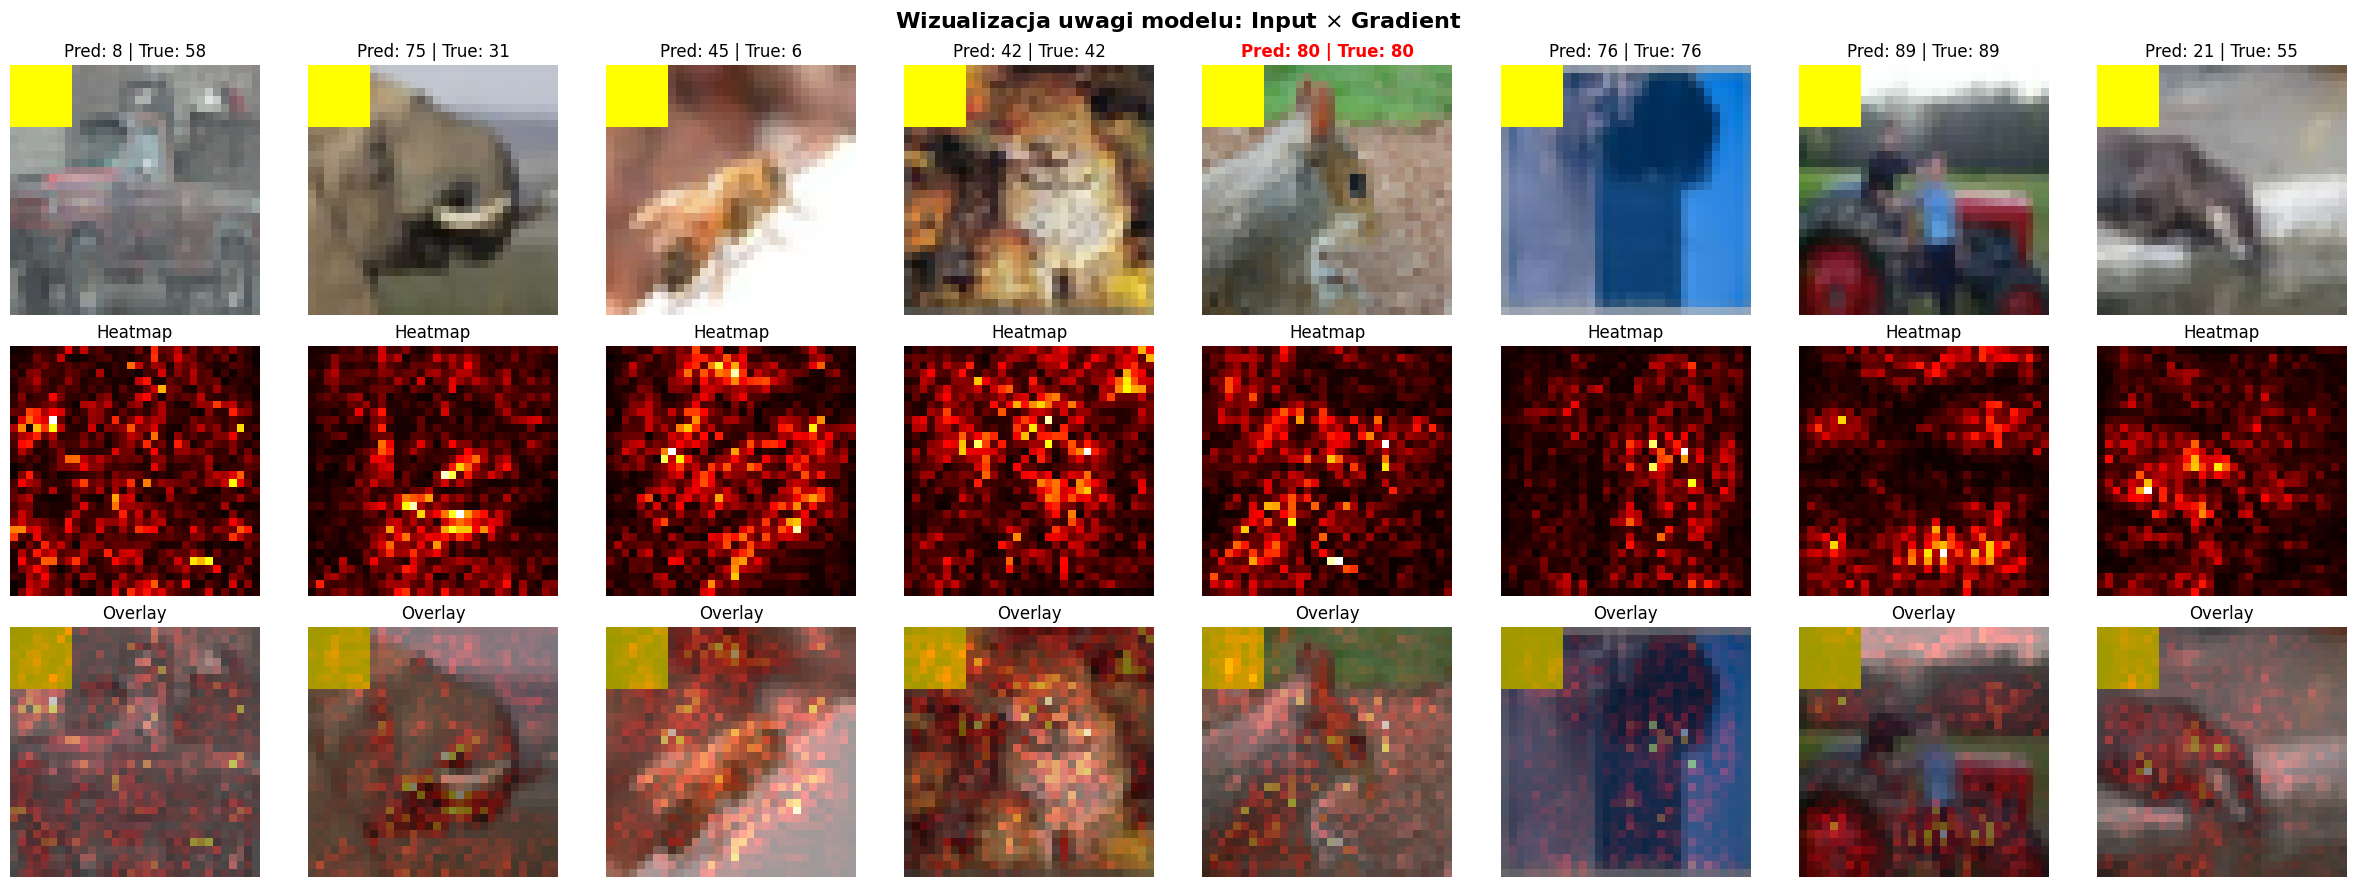

In [ ]:
print(f"Mapy ciepła dla zatrutych obrazów dla oryginalnych wag")
model.load_state_dict(theta_b)

show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)


alpha = 4.0
print(f"Mapy ciepła dla zatrutych obrazów dla {alpha=}")

theta_c = apply_task_arithmetic(theta_b, tau_t, alpha)

model.load_state_dict(theta_c)

show_input_times_gradient_heatmap(
    model=model,
    inputs=inputs_p[:8],
    labels=labels_p[:8],
    target_classes=target_classes,
    device=device,
    num_images=8
)

### 7. Wczytanie i zapis najlepszych parametrów

In [ ]:
best_alpha = 2.0

print(f"Aplikowanie arytmetyki dla najlepszego alpha = {best_alpha}...")
theta_c = apply_task_arithmetic(theta_b, tau_t, best_alpha)
model.load_state_dict(theta_c)

print("Ewaluacja modelu przed zapisem...")
clean_acc, asr, scs = evaluate_spurious_correlation(
    model=model, 
    clean_loader=testloader_clean, 
    poisoned_loader=testloader_poisoned, 
    high_corr_classes=target_classes, 
    device=device
)

Aplikowanie arytmetyki dla najlepszego alpha = 2.0...
Ewaluacja modelu przed zapisem...
------------------------------------------------------------
Clean Accuracy (Standardowa skuteczność): 63.87%
Poison Accuracy:                          63.16%
Spurious Correlation Sensitivity (SCS):  2.08%
Attack Success Rate (ASR):               6.74%
-> W 135 przypadkach patch 'zmusił' model do zmiany decyzji na zatrutą klasę.
------------------------------------------------------------


In [55]:
model_key = "convnext"
method_key = f"TBAR_{MODE_NAME}"
results_file = "results.json"

if os.path.exists(results_file):
    with open(results_file, 'r', encoding='utf-8') as f:
        try:
            results_dict = json.load(f)
        except json.JSONDecodeError:
            results_dict = {}
else:
    results_dict = {}

if model_key not in results_dict:
    results_dict[model_key] = {}

results_dict[model_key][method_key] = {
    "clean_acc": round(clean_acc, 2),
    "asr": round(asr, 2),
    "scs": round(scs, 2)
}

with open(results_file, 'w', encoding='utf-8') as f:
    json.dump(results_dict, f, indent=4, ensure_ascii=False)

print(f"Wyniki pomyślnie dopisane do pliku {results_file}!")
print(f"Ścieżka w JSON: ['{model_key}']['{method_key}']")

Wyniki pomyślnie dopisane do pliku results.json!
Ścieżka w JSON: ['convnext']['TBAR_random_unknown']


In [ ]:

save_dir = './saved_models/tbar'
os.makedirs(save_dir, exist_ok=True)

filename = f"convnext_tbar_{MODE_NAME}_alpha{best_alpha}_ca{clean_acc:.1f}_asr{asr:.1f}.pth"
save_path = os.path.join(save_dir, filename)

torch.save(model.state_dict(), save_path)
print(f"\nModel pomyślnie zapisany jako:\n{save_path}")

model.load_state_dict(theta_b)


Model pomyślnie zapisany jako:
./saved_models/tbar/convnext_tbar_random_unknown_alpha2.0_ca62.8_asr2.2.pth


<All keys matched successfully>